In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv('flood.csv')
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [17]:
print("\nFirst 5 rows of the dataset:")
print(df.head())


First 5 rows of the dataset:
   MonsoonIntensity  TopographyDrainage  RiverManagement  Deforestation  \
0                 3                   8                6              6   
1                 8                   4                5              7   
2                 3                  10                4              1   
3                 4                   4                2              7   
4                 3                   7                5              2   

   Urbanization  ClimateChange  DamsQuality  Siltation  AgriculturalPractices  \
0             4              4            6          2                      3   
1             7              9            1          5                      5   
2             7              5            4          7                      4   
3             3              4            1          4                      6   
4             5              8            5          2                      7   

   Encroachments  ...  DrainageS

In [18]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   MonsoonIntensity                 50000 non-null  int64  
 1   TopographyDrainage               50000 non-null  int64  
 2   RiverManagement                  50000 non-null  int64  
 3   Deforestation                    50000 non-null  int64  
 4   Urbanization                     50000 non-null  int64  
 5   ClimateChange                    50000 non-null  int64  
 6   DamsQuality                      50000 non-null  int64  
 7   Siltation                        50000 non-null  int64  
 8   AgriculturalPractices            50000 non-null  int64  
 9   Encroachments                    50000 non-null  int64  
 10  IneffectiveDisasterPreparedness  50000 non-null  int64  
 11  DrainageSystems                  50000 non-null  int64  
 12  Coa

In [19]:
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
MonsoonIntensity                   0
TopographyDrainage                 0
RiverManagement                    0
Deforestation                      0
Urbanization                       0
ClimateChange                      0
DamsQuality                        0
Siltation                          0
AgriculturalPractices              0
Encroachments                      0
IneffectiveDisasterPreparedness    0
DrainageSystems                    0
CoastalVulnerability               0
Landslides                         0
Watersheds                         0
DeterioratingInfrastructure        0
PopulationScore                    0
WetlandLoss                        0
InadequatePlanning                 0
PoliticalFactors                   0
FloodProbability                   0
dtype: int64



--- Performing Exploratory Data Analysis ---


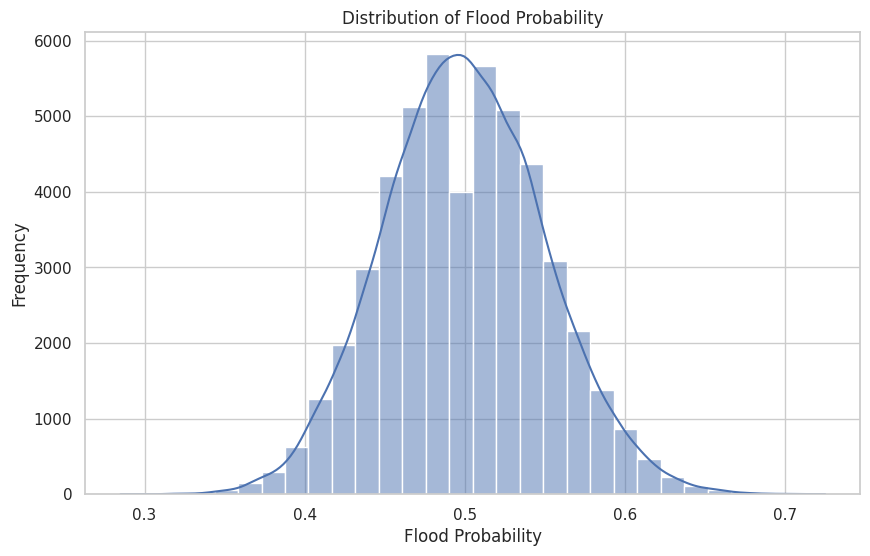

In [20]:
print("\n--- Performing Exploratory Data Analysis ---")
sns.set(style="whitegrid")

# Plot the distribution of the target variable 'FloodProbability'
plt.figure(figsize=(10, 6))
sns.histplot(df['FloodProbability'], kde=True, bins=30)
plt.title('Distribution of Flood Probability')
plt.xlabel('Flood Probability')
plt.ylabel('Frequency')
plt.show()

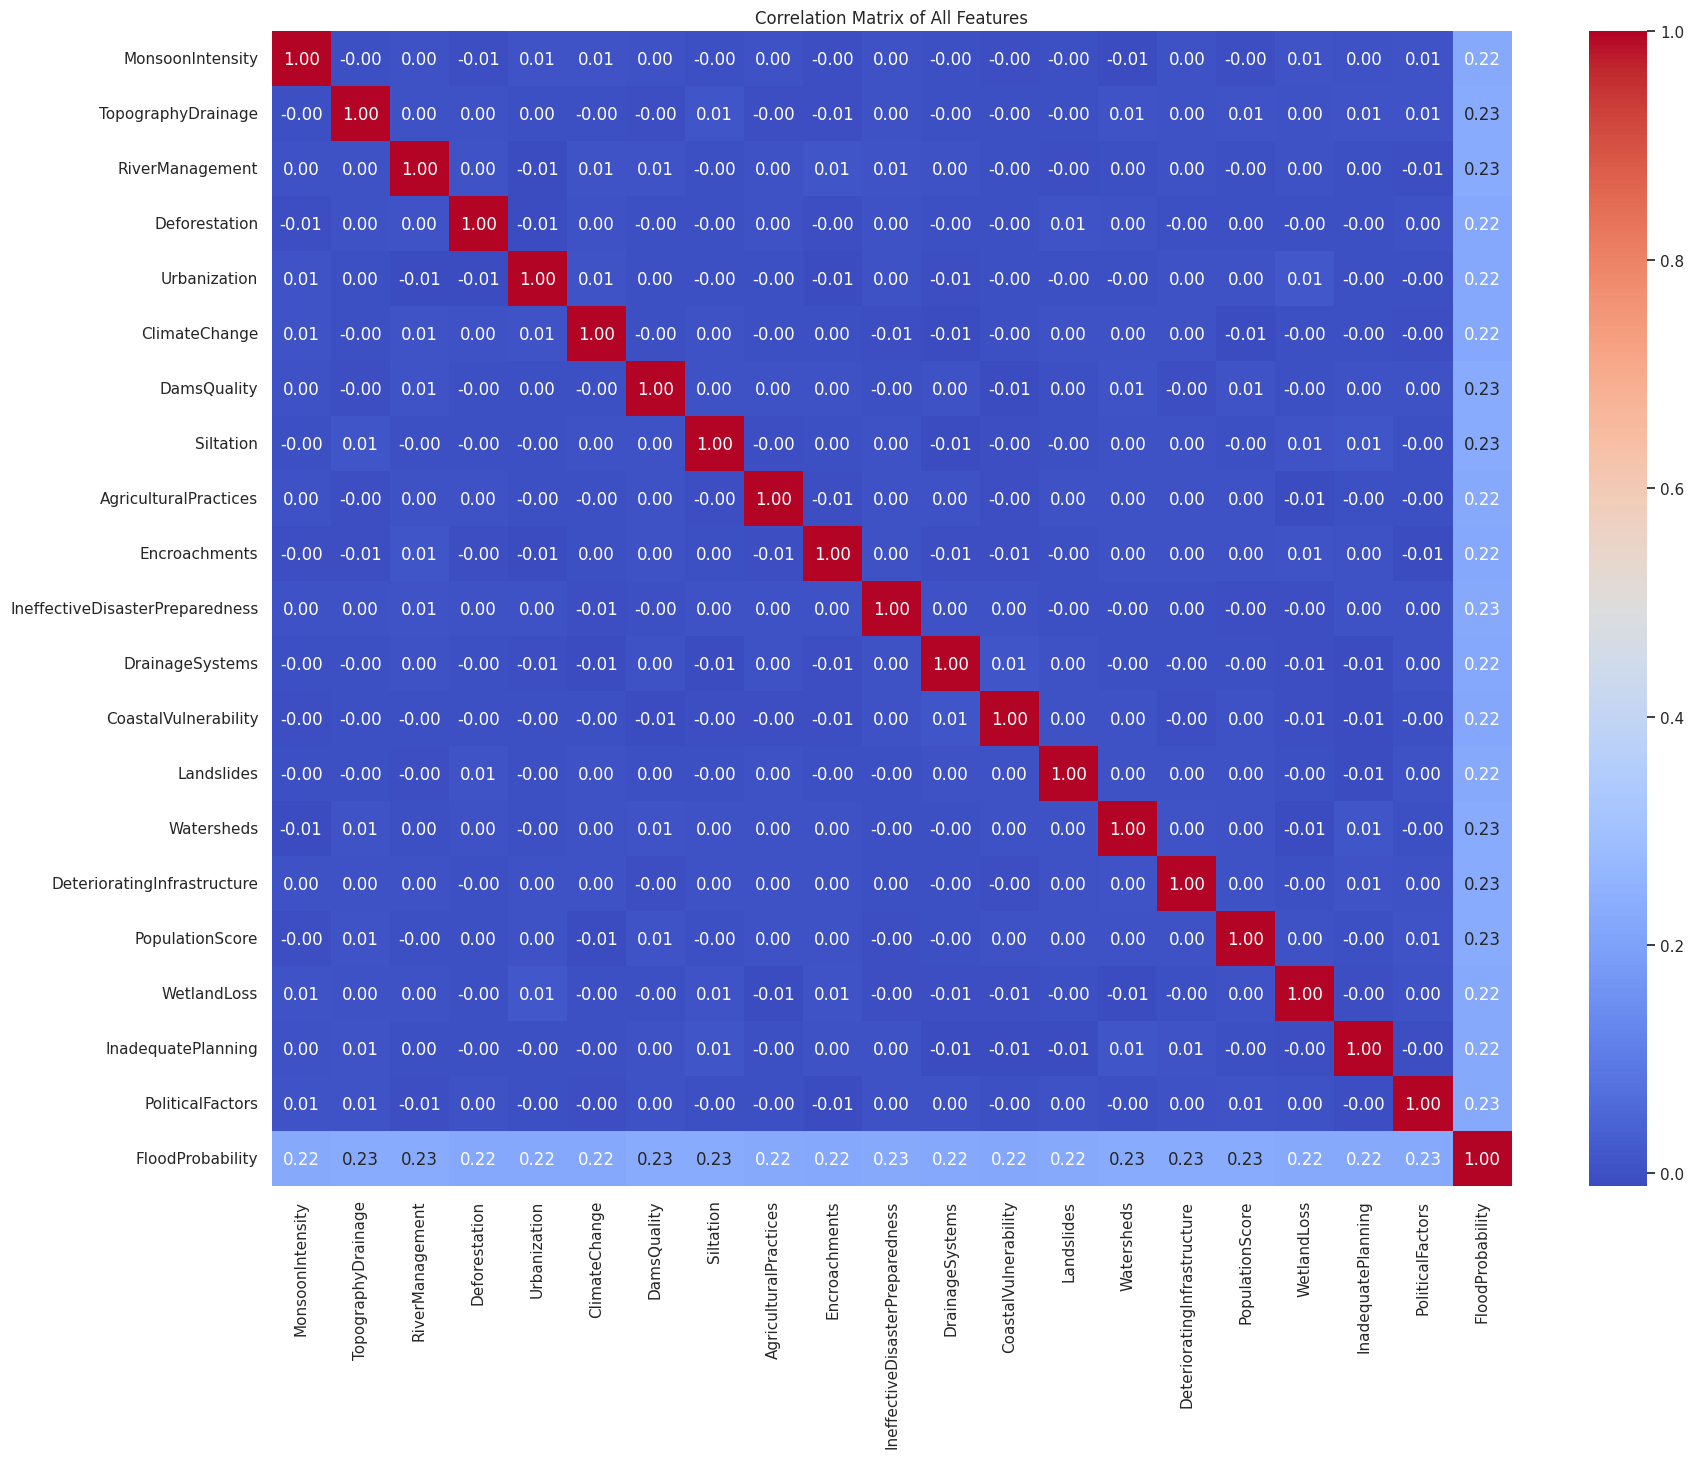

In [21]:
# Correlation Matrix to find relationships between variables
plt.figure(figsize=(20, 15))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of All Features')
plt.show()


Top 10 features most correlated with FloodProbability:
FloodProbability                   1.000000
DeterioratingInfrastructure        0.229444
TopographyDrainage                 0.229414
RiverManagement                    0.228917
Watersheds                         0.228152
DamsQuality                        0.227467
PopulationScore                    0.226928
Siltation                          0.226544
IneffectiveDisasterPreparedness    0.225126
PoliticalFactors                   0.225009
MonsoonIntensity                   0.224081
Name: FloodProbability, dtype: float64


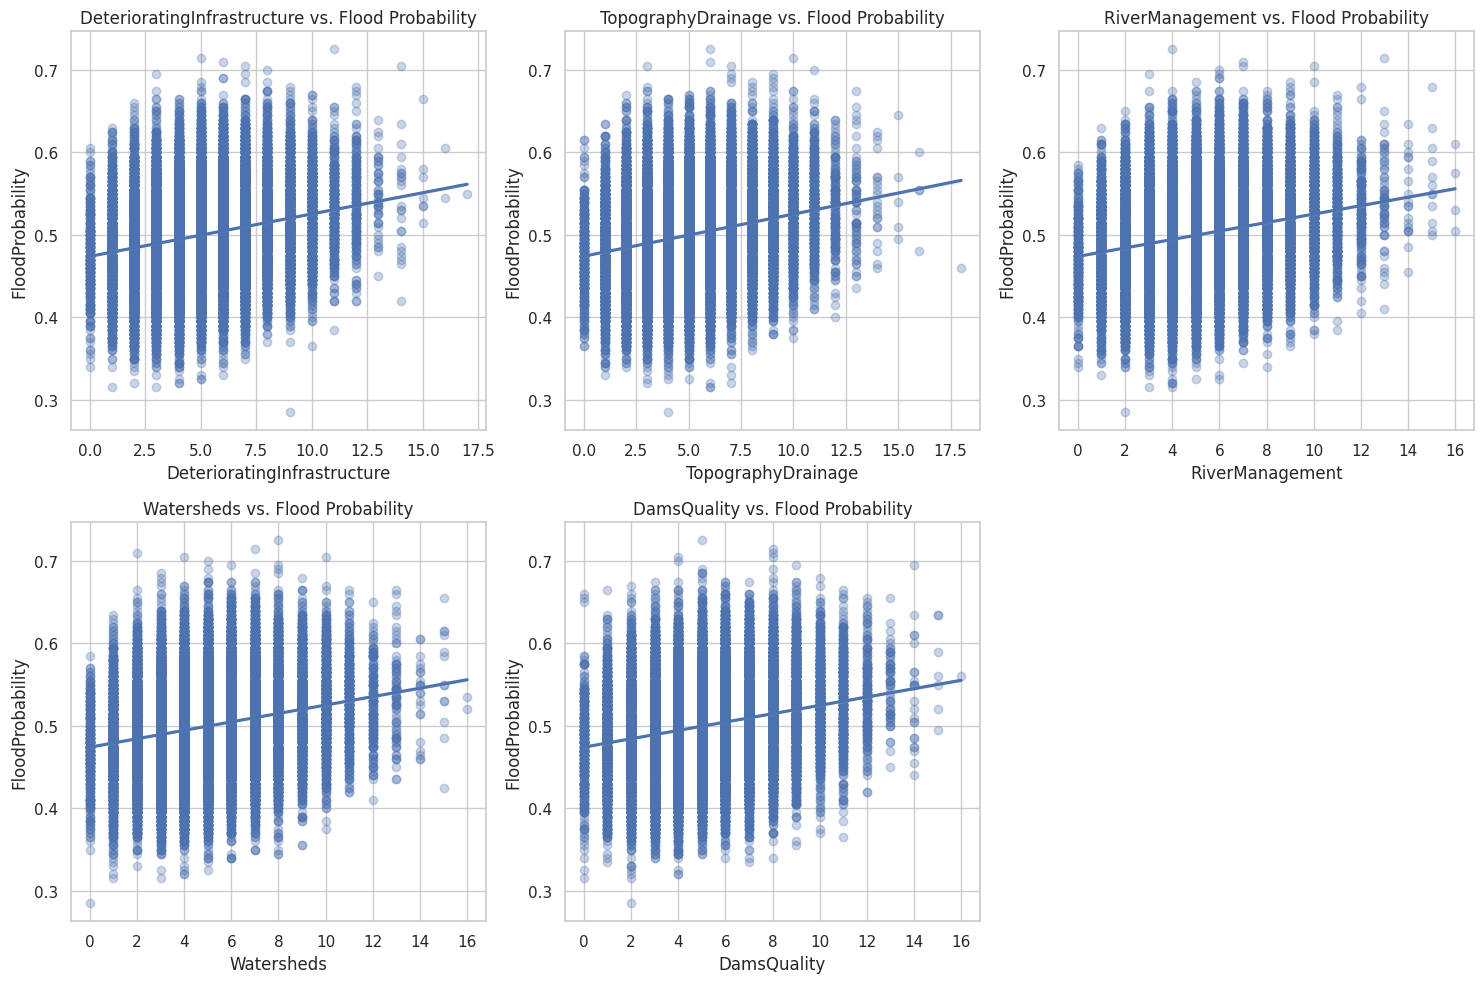

In [22]:
# Find features most correlated with FloodProbability
print("\nTop 10 features most correlated with FloodProbability:")
corr_with_target = correlation_matrix['FloodProbability'].abs().sort_values(ascending=False)
print(corr_with_target.head(11))

# Plotting the top 5 most correlated features against FloodProbability

top_5_features = corr_with_target.index[1:6]
plt.figure(figsize=(15, 10))
for i, col in enumerate(top_5_features):
    plt.subplot(2, 3, i + 1)
    sns.regplot(x=df[col], y=df['FloodProbability'], scatter_kws={'alpha':0.3})
    plt.title(f'{col} vs. Flood Probability')
plt.tight_layout()
plt.show()

In [23]:
print("\n--- Preprocessing ---")

# Splitting data into features (X) and target (y)
X = df.drop('FloodProbability', axis=1)
y = df['FloodProbability']

print("\nFeatures (X) and Target (y) have been separated.")


--- Preprocessing ---

Features (X) and Target (y) have been separated.


In [24]:
# Let's save the cleaned dataframe
df.to_csv('flood_cleaned.csv', index=False)
print("\nCleaned data saved to 'flood_cleaned.csv'")


Cleaned data saved to 'flood_cleaned.csv'
